# **ASSIGNMENT NO.4**

#### Problem Statement 1.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [3]:
print(df.isnull().sum())
df = df.dropna()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [4]:
marks = df["math score"]

print("Mean =", np.mean(marks))
print("Median =", np.median(marks))
print("Standard Deviation =", np.std(marks))

Mean = 66.089
Median = 66.0
Standard Deviation = 15.155496659628149


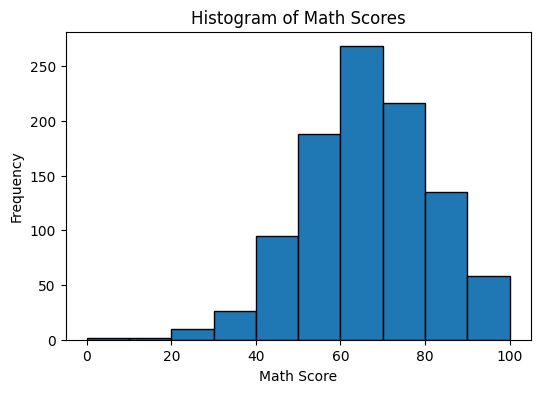

In [5]:
plt.figure(figsize=(6,4))
plt.hist(marks, bins=10, edgecolor="black")
plt.title("Histogram of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

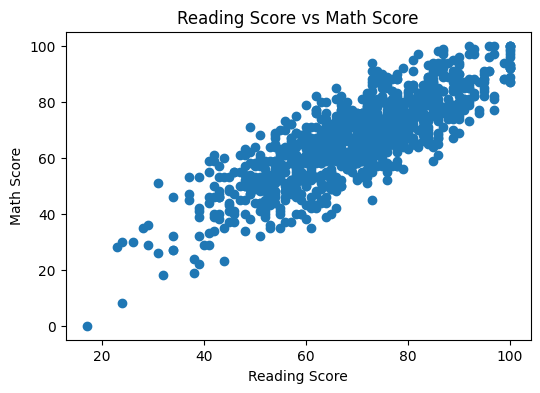

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(df["reading score"], df["math score"])

plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")

plt.show()

In [7]:
X = df[["reading score"]]
y = df["math score"]

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
predicted = model.predict(X)

print(predicted)

[68.49280267 83.77660631 88.02210732 55.75629964 73.58740389 77.8329049
 88.02210732 43.86889681 61.70000106 58.30360025 53.20899903 51.51079863
 76.13470449 68.49280267 52.35989883 71.04010328 82.92750611 34.52879459
 43.01979661 56.60539984 65.94550207 71.04010328 53.20899903 69.34190287
 67.64370247 70.19100308 53.20899903 65.94550207 66.79460227 66.79460227
 70.19100308 62.54910126 68.49280267 43.01979661 81.2293057  76.13470449
 76.13470449 61.70000106 83.77660631 54.90719944 59.15270045 69.34190287
 56.60539984 62.54910126 54.90719944 53.20899903 62.54910126 67.64370247
 70.19100308 78.6820051  54.05809924 65.94550207 44.71799701 73.58740389
 78.6820051  42.17069641 79.5311053  54.05809924 57.45450004 21.79229155
 70.19100308 40.472496   59.15270045 75.28560429 56.60539984 61.70000106
 38.7742956  68.49280267 56.60539984 61.70000106 60.85090085 54.05809924
 50.66169843 55.75629964 48.96349802 42.17069641 29.43419337 73.58740389
 70.19100308 65.09640186 48.96349802 45.56709721 47.

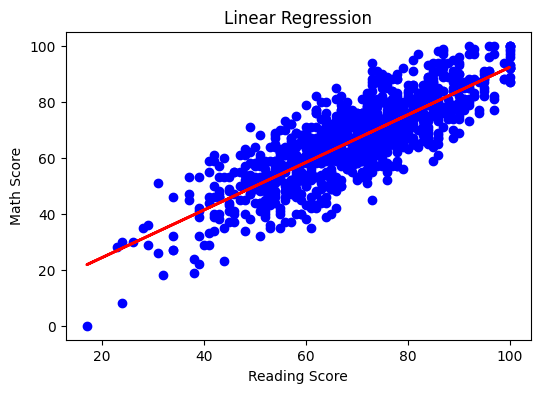

In [9]:
plt.figure(figsize=(6,4))

plt.scatter(X, y, color="blue")

plt.plot(X, predicted, color="red", linewidth=2)

plt.title("Linear Regression")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")

plt.show()

In [10]:
print("Slope =", model.coef_[0])
print("Intercept =", model.intercept_)

Slope = 0.849100202134806
Intercept = 7.357588118537606


#### Problem Statement 2. (Car Mileage Prediction)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [3]:
data = pd.read_csv("Car_Mileage_Data.csv")
data

,Engine_Size_Liters,Car_Weight_kg,Horsepower,MPG
0,2.498160,1370.265858,150.660535,31.013611
1,4.802857,2083.801895,146.684276,16.268459
2,3.927976,2745.891672,324.688737,13.468015
3,3.394634,2464.449773,147.377474,16.722438
4,1.624075,2613.122296,153.426426,28.981412
...,...,...,...,...
995,1.366328,2313.910313,313.629855,29.266311
996,4.669254,2913.229242,122.463766,11.404165
997,1.547275,1137.916033,163.642722,37.255994
998,4.800949,1114.109442,158.312294,21.016797


In [4]:
data.describe()

,Engine_Size_Liters,Car_Weight_kg,Horsepower,MPG
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.961026,2014.034610,215.649546,22.296792
std,1.168549,584.379787,78.482033,6.711277
min,1.018528,1006.436527,80.003141,5.488195
25%,1.943893,1482.148542,150.564764,17.338034
50%,2.987230,2037.467813,215.165758,22.489929
75%,3.977278,2520.930115,284.957952,27.108267
max,4.998871,2998.827452,349.411631,37.584397


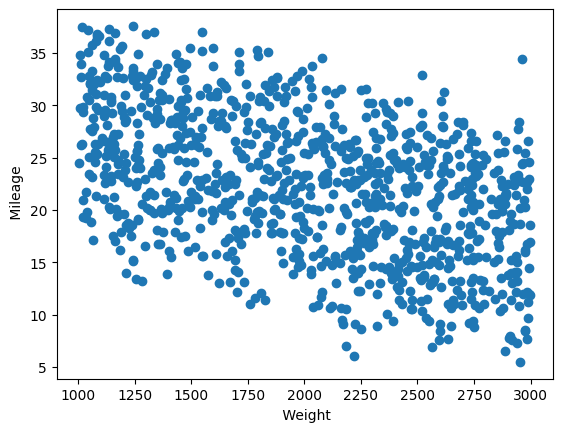

In [5]:
plt.scatter(data["Car_Weight_kg"],data["MPG"])
plt.xlabel(" Weight")
plt.ylabel(" Mileage")
plt.show()

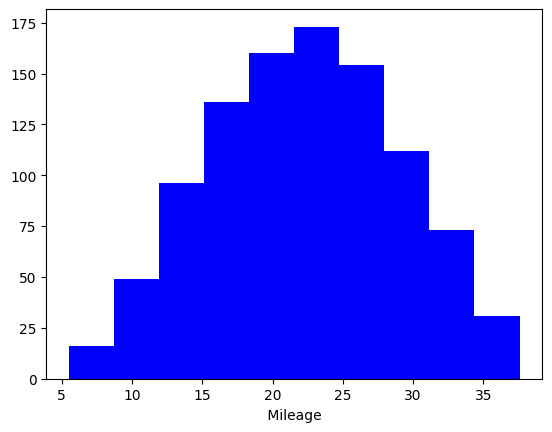

In [6]:
plt.hist(data["MPG"],color='blue')
plt.xlabel(" Mileage ")
plt.show()

In [7]:
x = data[["Engine_Size_Liters"]]
y = data["MPG"]

In [8]:
lr = LinearRegression()
lr.fit(x,y)
pred = lr.predict(x)
pred

array([24.45129168, 13.72362619, 17.79593446, 20.27847918, 28.51989693,
       28.52034602, 30.34332854, 15.29762434, 20.23274161, 18.24132128,
       31.04151669, 13.36622838, 15.92570135, 27.471278  , 28.03941439,
       28.01000522, 25.76015299, 21.65444589, 23.38248198, 26.0024412 ,
       20.03281524, 28.82756832, 25.98539554, 24.60356127, 22.93330434,
       16.80574967, 27.70709107, 21.85035266, 20.39473332, 30.55992462,
       20.11302578, 28.24982241, 30.21359318, 13.75767565, 13.44587619,
       16.37339557, 25.75323562, 29.60623859, 18.68518485, 23.22966874,
       29.15257093, 22.20518075, 30.78450244, 14.49433055, 26.60660523,
       19.08941257, 25.62109236, 21.74173841, 21.24569183, 27.98300898,
       13.37228366, 16.99274073, 13.9324427 , 14.76417362, 20.29260163,
       14.26059339, 29.77715184, 27.77581153, 30.58269771, 25.36751834,
       24.18807469, 26.37258474, 15.99468641, 24.78246021, 26.19411475,
       21.3204313 , 28.80093667, 16.4888389 , 30.03673236, 13.05

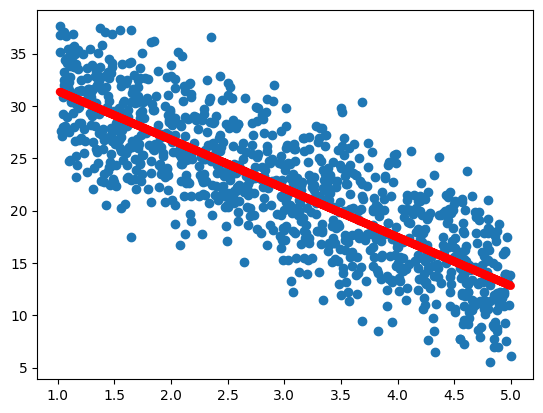

In [9]:
plt.scatter(x,y)
plt.plot(x,pred,color='red',linewidth=6)
plt.show()